In [ ]:
import h5py

FILE_PATH = r"D:\seismic\raw_data\20230516\Brienz_20Hz_4m_20230516_124613.500.h5"

def explore_h5(name, node):
    if isinstance(node, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {node.shape} | Data Type: {node.dtype}")
    elif isinstance(node, h5py.Group):
        print(f"Group: {name}")

print(f"Cracking open {FILE_PATH}...\n" + "="*40)
with h5py.File(FILE_PATH, 'r') as f:
    f.visititems(explore_h5)

Cracking open D:\seismic\raw_data\20230516\Brienz_20Hz_4m_20230516_124613.500.h5...
Dataset: Distance | Shape: (512, 1) | Data Type: float64
Dataset: Traces | Shape: (6000, 512) | Data Type: float32


In [ ]:
#! Module 1 Preprocessing

import numpy as np
import h5py
import os
import glob
import random
from scipy import signal
from tqdm import tqdm

# --- CONFIGURATION --
RAW_DATA_ROOT = r"D:\seismic\raw_data"
OUTPUT_FILE = r"D:\seismic\vqvae_unsupervised_dataset_v2.npy"

# DATA PARAMS
FS = 20.0
WINDOW_SECONDS = 30
FILE_DURATION_SEC = 300 # Each .h5 file is 5 minutes
WINDOW_SIZE = int(WINDOW_SECONDS * FS) # 600 samples
STRIDE = WINDOW_SIZE # Non-overlapping chunks (set smaller for overlap)

# SPATIAL CHANNELS (DAS has 512 channels)
# We pick 3 distinct channels to create a 3-Channel "Image" (Like RGB)
# This captures behavior at the start, middle, and end of the fiber.
CHANNELS_TO_USE = [100, 256, 400]

def compute_3ch_spectrogram(waveform_chunk, fs):
    """
    Input: (Time, 512) raw data
    Output: (3, Freq, Time) spectrogram image
    """
    specs = []

    # Generate a spectrogram for each selected spatial channel
    for ch_idx in CHANNELS_TO_USE:
        # 1. Extract specific fiber channel
        trace = waveform_chunk[:, ch_idx]

        # 2. Compute Spectrogram
        # nperseg=64 gives 33 freq bins. Adjust if you want larger images.
        f, t, Sxx = signal.spectrogram(trace, fs, nperseg=64, noverlap=32)

        # 3. Log Scale & Normalize
        Sxx = np.log1p(Sxx)

        # Robust min-max normalization per channel
        # (Avoids squashing silent channels if one is loud)
        min_val = Sxx.min()
        max_val = Sxx.max()
        if max_val - min_val > 0:
            Sxx = (Sxx - min_val) / (max_val - min_val)
        else:
            Sxx = np.zeros_like(Sxx)

        specs.append(Sxx)

    # Stack to create (3, H, W)
    return np.array(specs)

def generate_unsupervised_dataset():
    print(f"🚀 Starting Unsupervised Data Scan in: {RAW_DATA_ROOT}")

    # 1. Get list of all daily folders (20230516, etc.)
    all_folders = [f for f in os.listdir(RAW_DATA_ROOT)
                   if os.path.isdir(os.path.join(RAW_DATA_ROOT, f)) and f.startswith("20")]

    if len(all_folders) < 15:
        print(f"⚠️ Warning: Only found {len(all_folders)} folders. Using all of them.")
        selected_folders = all_folders
    else:
        # Randomly select 15 folders
        selected_folders = random.sample(all_folders, 15)
        print(f"🎲 Randomly selected 15 folders: {selected_folders}")

    dataset_images = []

    # 2. Iterate through selected folders
    for folder in tqdm(selected_folders, desc="Processing Folders"):
        folder_path = os.path.join(RAW_DATA_ROOT, folder)
        h5_files = glob.glob(os.path.join(folder_path, "*.h5"))

        # Process every file in the folder
        for f_path in h5_files:
            try:
                with h5py.File(f_path, 'r') as f:
                    # Shape: (6000, 512) typically
                    full_trace = f['Traces'][:]

                    # 3. Sliding Window Slicing
                    # Slice the 5-minute file into 30s chunks
                    num_samples = full_trace.shape[0]

                    for start_idx in range(0, num_samples - WINDOW_SIZE + 1, STRIDE):
                        end_idx = start_idx + WINDOW_SIZE

                        # Extract (600, 512) chunk
                        chunk = full_trace[start_idx:end_idx, :]

                        # Compute 3-Channel Spectrogram
                        # Shape result: (3, 33, 17) depending on spectrogram params
                        spec_img = compute_3ch_spectrogram(chunk, FS)

                        dataset_images.append(spec_img)

            except Exception as e:
                # Catch corrupt files and skip
                continue

    # 4. Save Final Dataset
    dataset_images = np.array(dataset_images, dtype=np.float32)

    print("="*50)
    print(f"✅ Processing Complete.")
    print(f"📊 Final Dataset Shape: {dataset_images.shape}")
    print(f"   (Samples, Channels, Freq, Time)")
    print(f"💾 Saving to {OUTPUT_FILE}...")

    np.save(OUTPUT_FILE, dataset_images)
    print("🎉 Done! Ready for VQ-VAE training.")

if __name__ == "__main__":
    generate_unsupervised_dataset()

🚀 Starting Unsupervised Data Scan in: D:\seismic\raw_data
🎲 Randomly selected 15 folders: ['20230618', '20230626', '20230612', '20230620', '20230613', '20230628', '20230603', '20230611', '20230521', '20230604', '20230527', '20230630', '20230520', '20230621', '20230516']


Processing Folders: 100%|██████████████████████████████████████████████████████████████| 15/15 [10:57<00:00, 43.80s/it]


✅ Processing Complete.
📊 Final Dataset Shape: (39450, 3, 33, 17)
   (Samples, Channels, Freq, Time)
💾 Saving to D:\seismic\vqvae_unsupervised_dataset_v2.npy...
🎉 Done! Ready for VQ-VAE training.


🔍 Scanning for files...
📄 Visualizing: Brienz_20Hz_4m_20230527_101613.172.h5


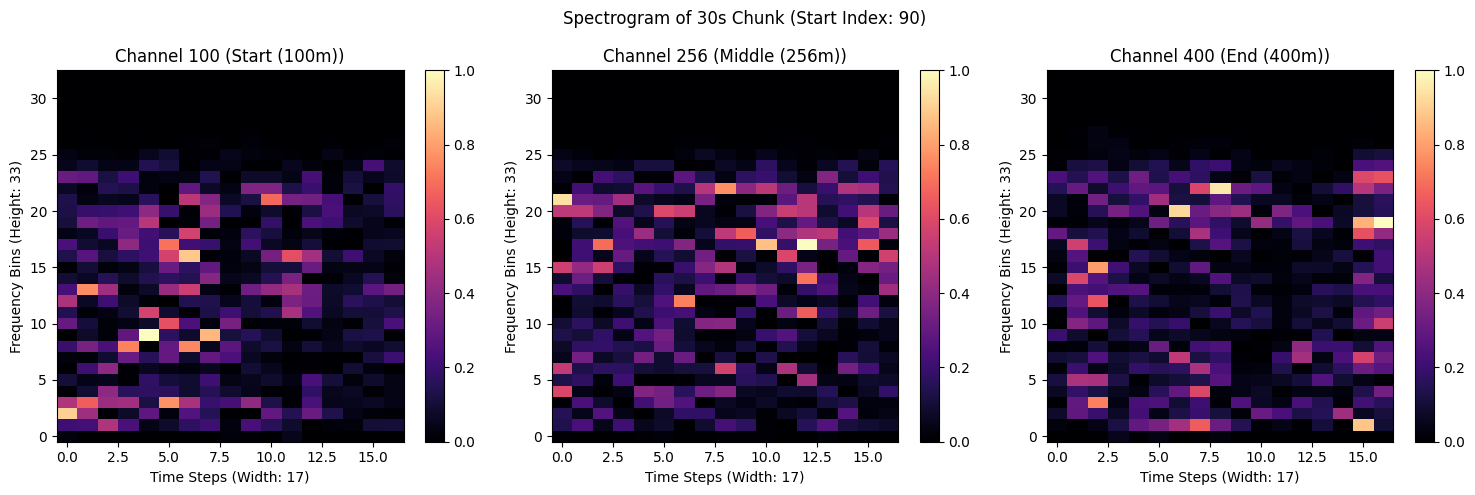

In [ ]:
# Juat to show spectograms

import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import random
from scipy import signal

# --- CONFIGURATION ---
RAW_DATA_ROOT = r"D:\seismic\raw_data"
FS = 20.0
CHANNELS_TO_USE = [100, 256, 400] # Red, Green, Blue channels

def compute_spectrogram(trace, fs):
    # Same logic as your main script
    f, t, Sxx = signal.spectrogram(trace, fs, nperseg=64, noverlap=32)
    Sxx = np.log1p(Sxx)

    # Normalize 0-1
    min_val, max_val = Sxx.min(), Sxx.max()
    if max_val - min_val > 0:
        Sxx = (Sxx - min_val) / (max_val - min_val)
    return f, t, Sxx

def show_random_spectrogram():
    # 1. Find a random file
    all_files = []
    print("🔍 Scanning for files...")
    for root, dirs, files in os.walk(RAW_DATA_ROOT):
        for file in files:
            if file.endswith(".h5"):
                all_files.append(os.path.join(root, file))

    if not all_files:
        print("❌ No files found in D:\\seismic\\raw_data")
        return

    random_file = random.choice(all_files)
    print(f"📄 Visualizing: {os.path.basename(random_file)}")

    with h5py.File(random_file, 'r') as f:
        # 2. Grab a random 30-second chunk (600 samples)
        total_len = f['Traces'].shape[0]
        start_idx = random.randint(0, total_len - 600)
        end_idx = start_idx + 600

        # 3. Plot the 3 channels
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        channel_names = ["Start (100m)", "Middle (256m)", "End (400m)"]

        for i, ch_idx in enumerate(CHANNELS_TO_USE):
            trace = f['Traces'][start_idx:end_idx, ch_idx]

            # Compute Spectrogram
            freqs, times, img = compute_spectrogram(trace, FS)

            # Display
            # origin='lower' puts 0Hz at the bottom
            # aspect='auto' stretches the pixels to fill the square
            im = axes[i].imshow(img, aspect='auto', origin='lower', cmap='magma')

            axes[i].set_title(f"Channel {ch_idx} ({channel_names[i]})")
            axes[i].set_xlabel("Time Steps (Width: 17)")
            axes[i].set_ylabel("Frequency Bins (Height: 33)")
            fig.colorbar(im, ax=axes[i])

        plt.suptitle(f"Spectrogram of 30s Chunk (Start Index: {start_idx})")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    show_random_spectrogram()

🚀 Initializing VQ-VAE on cpu...
📂 Loading D:\seismic\vqvae_unsupervised_dataset_v2.npy into RAM...
✅ Loaded. Raw Shape: (39450, 3, 33, 17)
Epoch 1 [0/617] Loss: 0.0182 | Recon: 0.0123
Epoch 1 [100/617] Loss: 0.0078 | Recon: 0.0077
Epoch 1 [200/617] Loss: 0.0070 | Recon: 0.0069
Epoch 1 [300/617] Loss: 0.0070 | Recon: 0.0068
Epoch 1 [400/617] Loss: 0.0062 | Recon: 0.0060
Epoch 1 [500/617] Loss: 0.0068 | Recon: 0.0066
Epoch 1 [600/617] Loss: 0.0068 | Recon: 0.0065
====> Epoch: 1 Average Loss: 0.0072
Epoch 2 [0/617] Loss: 0.0065 | Recon: 0.0063
Epoch 2 [100/617] Loss: 0.0066 | Recon: 0.0063
Epoch 2 [200/617] Loss: 0.0065 | Recon: 0.0062
Epoch 2 [300/617] Loss: 0.0058 | Recon: 0.0055
Epoch 2 [400/617] Loss: 0.0066 | Recon: 0.0061
Epoch 2 [500/617] Loss: 0.0064 | Recon: 0.0060
Epoch 2 [600/617] Loss: 0.0066 | Recon: 0.0062
====> Epoch: 2 Average Loss: 0.0065
Epoch 3 [0/617] Loss: 0.0069 | Recon: 0.0064
Epoch 3 [100/617] Loss: 0.0065 | Recon: 0.0061
Epoch 3 [200/617] Loss: 0.0066 | Recon: 0.0

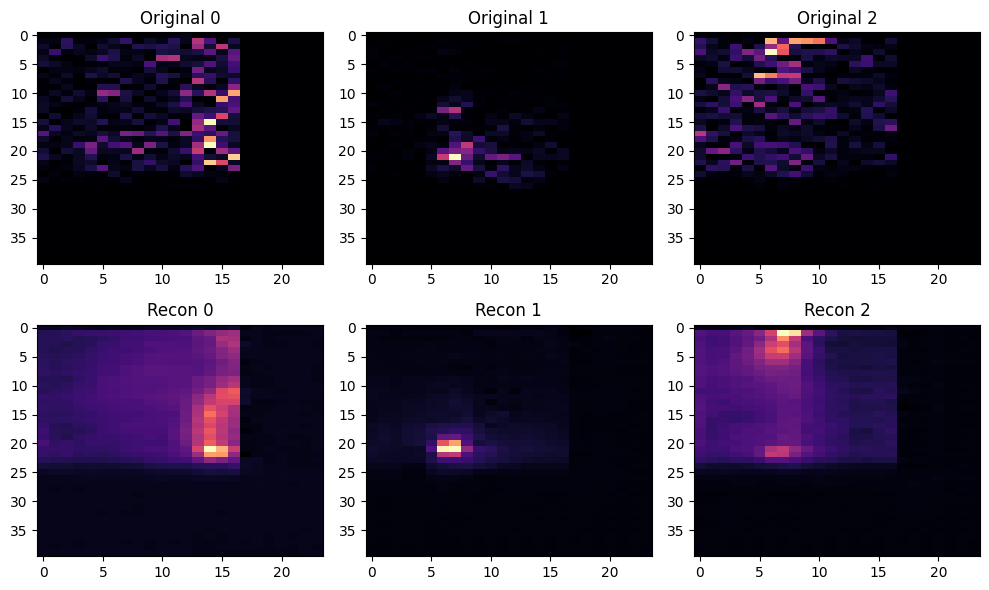

In [ ]:
#Module 2 Training VQAE

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATASET_PATH = r"D:\seismic\vqvae_unsupervised_dataset_v2.npy"
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
EMBEDDING_DIM = 64   # Size of each vector in codebook
NUM_EMBEDDINGS = 128 # Size of the dictionary (how many "words" the AI knows)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. DATA LOADER WITH PADDING ---
class SeismicDataset(Dataset):
    def __init__(self, npy_file):
        print(f"📂 Loading {npy_file} into RAM...")
        self.data = np.load(npy_file) # Shape (43200, 3, 33, 17)
        print(f"✅ Loaded. Raw Shape: {self.data.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get sample (3, 33, 17)
        x = torch.from_numpy(self.data[idx]).float()

        # PAD TO (3, 40, 24) for divisibility by 8
        # Pad format: (Left, Right, Top, Bottom)
        # 17 -> 24 (Need +7 width) | 33 -> 40 (Need +7 height)
        pad_w = 24 - 17
        pad_h = 40 - 33

        # Use simple zero padding (bottom and right)
        x_padded = F.pad(x, (0, pad_w, 0, pad_h), "constant", 0)

        return x_padded

# --- 2. VECTOR QUANTIZER LAYER ---
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super(VectorQuantizer, self).__init__()
        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings
        self._commitment_cost = commitment_cost

        # The Codebook
        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.uniform_(-1/self._num_embeddings, 1/self._num_embeddings)

    def forward(self, inputs):
        # Inputs: (Batch, Channel, Height, Width) -> Permute to (Batch, H, W, Channel)
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        input_shape = inputs.shape

        # Flatten
        flat_input = inputs.view(-1, self._embedding_dim)

        # Calculate distances
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True)
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        # Encoding
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)

        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)

        # Loss
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)
        q_latent_loss = F.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self._commitment_cost * e_latent_loss

        # Straight Through Estimator
        quantized = inputs + (quantized - inputs).detach()

        # Permute back to (Batch, Channel, Height, Width)
        return loss, quantized.permute(0, 3, 1, 2).contiguous(), encodings, encoding_indices

# --- 3. THE VQ-VAE MODEL ---
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        super(ResidualBlock, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            nn.Conv2d(in_channels=in_channels, out_channels=num_residual_hiddens, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(True),
            nn.Conv2d(in_channels=num_residual_hiddens, out_channels=num_hiddens, kernel_size=1, stride=1, bias=False)
        )
    def forward(self, x):
        return x + self._block(x)

class SeismicVQVAE(nn.Module):
    def __init__(self, num_hiddens, num_residual_layers, num_residual_hiddens,
                 num_embeddings, embedding_dim, commitment_cost=0.25):
        super(SeismicVQVAE, self).__init__()

        # Encoder: 3 -> 40 -> 24 downsamples 3 times -> (3, 5, 3) latent map
        self._encoder = nn.Sequential(
            nn.Conv2d(3, num_hiddens // 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(num_hiddens // 2, num_hiddens, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(num_hiddens, num_hiddens, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(num_hiddens, embedding_dim, kernel_size=3, stride=1, padding=1)
        )

        # Residual stack for better feature extraction
        self._pre_vq_conv = nn.Conv2d(embedding_dim, embedding_dim, kernel_size=1, stride=1)

        self._vq_vae = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)

        # Decoder: Upsamples back to (3, 40, 24)
        self._decoder = nn.Sequential(
            nn.Conv2d(embedding_dim, num_hiddens, kernel_size=3, stride=1, padding=1),
            ResidualBlock(num_hiddens, num_hiddens, num_residual_hiddens),
            ResidualBlock(num_hiddens, num_hiddens, num_residual_hiddens),
            nn.ConvTranspose2d(num_hiddens, num_hiddens, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(num_hiddens, num_hiddens // 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(num_hiddens // 2, 3, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        z = self._encoder(x)
        z = self._pre_vq_conv(z)
        loss, quantized, perplexity, _ = self._vq_vae(z)
        x_recon = self._decoder(quantized)
        return loss, x_recon, perplexity

# --- 4. TRAINING LOOP ---
def train():
    print(f"🚀 Initializing VQ-VAE on {DEVICE}...")
    dataset = SeismicDataset(DATASET_PATH)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    model = SeismicVQVAE(num_hiddens=128, num_residual_layers=2, num_residual_hiddens=32,
                         num_embeddings=NUM_EMBEDDINGS, embedding_dim=EMBEDDING_DIM).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, amsgrad=False,fused=False)

    losses = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        train_recon_error = 0

        for batch_idx, data in enumerate(dataloader):
            data = data.to(DEVICE)
            optimizer.zero_grad()

            vq_loss, data_recon, _ = model(data)
            recon_error = F.mse_loss(data_recon, data)
            loss = recon_error + vq_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_recon_error += recon_error.item()

            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1} [{batch_idx}/{len(dataloader)}] Loss: {loss.item():.4f} | Recon: {recon_error.item():.4f}')

        avg_loss = train_loss / len(dataloader)
        losses.append(avg_loss)
        print(f'====> Epoch: {epoch+1} Average Loss: {avg_loss:.4f}')

    # --- SAVE MODEL ---
    SAFE_MODEL_PATH = r"D:\seismic\seismic_vqvae_v2.pth"
    torch.save(model.state_dict(), SAFE_MODEL_PATH)
    print(f"💾 Model Saved: {SAFE_MODEL_PATH}")

    # --- VISUALIZATION ---

    SAFE_IMG_PATH = r"D:\seismic\reconstruction_results.png"

    model.eval()
    with torch.no_grad():
        # Get one batch
        sample = next(iter(dataloader)).to(DEVICE)
        _, recon, _ = model(sample)

        # Plot Original vs Recon
        fig, ax = plt.subplots(2, 3, figsize=(10, 6))
        for i in range(3):
            # Original
            ax[0, i].imshow(sample[i].cpu().permute(1, 2, 0).numpy()[:,:,0], aspect='auto', cmap='magma')
            ax[0, i].set_title(f"Original {i}")
            # Reconstruction
            ax[1, i].imshow(recon[i].cpu().permute(1, 2, 0).numpy()[:,:,0], aspect='auto', cmap='magma')
            ax[1, i].set_title(f"Recon {i}")
        plt.tight_layout()
        plt.savefig(SAFE_IMG_PATH)
        print(f"🖼️ Check '{SAFE_IMG_PATH}' to see performance.")

if __name__ == "__main__":
    train()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import h5py
import os
import glob
from datetime import datetime, timedelta
from scipy import signal
from tqdm import tqdm
from scipy.stats import skew, kurtosis

# ==========================================
# --- CONFIGURATION ---
# ==========================================
LABEL_FILE = r"D:\seismic\output\labels\labels.csv"
RAW_DATA_ROOT = r"D:\seismic\raw_data"
MODEL_PATH = r"D:\seismic\seismic_vqvae_v2.pth"
OUTPUT_FILE = r"D:\seismic\rich_features_dataset_augmented.npz"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHANNELS_TO_USE = [100, 256, 400]
FS = 20.0
WINDOW_SECONDS = 30
WINDOW_SIZE = int(WINDOW_SECONDS * FS)
HALF_WINDOW = WINDOW_SIZE // 2

# --- MODEL (Encoder Only) ---
class SeismicEncoder(nn.Module):
    def __init__(self, num_hiddens, num_embeddings, embedding_dim):
        super(SeismicEncoder, self).__init__()
        self._encoder = nn.Sequential(
            nn.Conv2d(3, num_hiddens // 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(num_hiddens // 2, num_hiddens, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(num_hiddens, num_hiddens, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(num_hiddens, embedding_dim, kernel_size=3, stride=1, padding=1)
        )
        self._pre_vq_conv = nn.Conv2d(embedding_dim, embedding_dim, kernel_size=1, stride=1)

    def forward(self, x):
        z = self._encoder(x)
        z = self._pre_vq_conv(z)
        return z

# --- HELPERS ---
def compute_3ch_spectrogram(waveform_chunk, fs):
    specs = []
    for ch_idx in [0, 1, 2]:
        trace = waveform_chunk[:, ch_idx]
        f, t, Sxx = signal.spectrogram(trace, fs, nperseg=64, noverlap=32)
        Sxx = np.log1p(Sxx)
        min_val, max_val = Sxx.min(), Sxx.max()
        if max_val - min_val > 0:
            Sxx = (Sxx - min_val) / (max_val - min_val)
        else:
            Sxx = np.zeros_like(Sxx)
        specs.append(Sxx)
    return np.array(specs)

# 🚀 HYBRID UPGRADE 1: The Classical Physics Engine
def compute_classical_features(waveform_chunk):
    features = []
    for ch_idx in range(waveform_chunk.shape[1]):
        trace = waveform_chunk[:, ch_idx]

        # Base 5
        max_amp = np.max(np.abs(trace))
        variance = np.var(trace)
        energy = np.sum(trace ** 2)
        zcr = np.sum(np.diff(np.sign(trace)) != 0)
        mav = np.mean(np.abs(trace))

        # The 3 New Advanced Stats
        skewness = skew(trace)
        kurt = kurtosis(trace)

        # FFT for Peak Frequency
        freqs = np.fft.fftfreq(len(trace), d=1/FS)
        fft_mags = np.abs(np.fft.fft(trace))
        peak_freq = np.abs(freqs[np.argmax(fft_mags[1:]) + 1]) # Ignore DC offset

        features.extend([max_amp, variance, energy, zcr, mav, skewness, kurt, peak_freq])

    return np.array(features)

def generate_augmented_features():
    print(f"🚀 Loading VQ-VAE Encoder on {DEVICE}...")
    model = SeismicEncoder(num_hiddens=128, num_embeddings=128, embedding_dim=64).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE), strict=False)
    model.eval()

    print(f"📄 Processing Labels & Augmenting Data...")
    df = pd.read_csv(LABEL_FILE)
    df['dt'] = pd.to_datetime(df['time'])

    file_map = {}
    all_files = glob.glob(os.path.join(RAW_DATA_ROOT, "**", "*.h5"), recursive=True)
    for f_path in all_files:
        try:
            parts = os.path.basename(f_path).split('_')
            if len(parts) >= 5:
                dt_str = f"{parts[3]} {parts[4].replace('.h5', '')}"
                dt = datetime.strptime(dt_str, "%Y%m%d %H%M%S.%f")
                file_map[dt] = f_path
        except: continue
    sorted_starts = sorted(file_map.keys())

    X_features = []
    y_labels = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
        target = row['dt']
        label = row['label']
        f_path = None
        f_start = None

        for start_t in reversed(sorted_starts):
            if start_t <= target < (start_t + timedelta(seconds=300)):
                f_path = file_map[start_t]
                f_start = start_t
                break

        if not f_path: continue

        try:
            with h5py.File(f_path, 'r') as f:
                base_idx = int((target - f_start).total_seconds() * FS)

                if label in [1, 2, 3]:
                    shift_seconds = [-10, -5, 0, 5, 10]
                else:
                    shift_seconds = [0]

                for shift in shift_seconds:
                    shift_idx = int(shift * FS)
                    center_idx = base_idx + shift_idx
                    s_idx, e_idx = center_idx - HALF_WINDOW, center_idx + HALF_WINDOW

                    if s_idx < 0 or e_idx > f['Traces'].shape[0]:
                        continue

                    # The raw (600, 3) seismic wave block
                    raw_chunk = f['Traces'][s_idx:e_idx, CHANNELS_TO_USE]

                    # 1. Get Deep Learning Features (from spectrogram)
                    spec = compute_3ch_spectrogram(raw_chunk, FS)
                    tensor_x = torch.from_numpy(spec).float().unsqueeze(0).to(DEVICE)
                    tensor_x = F.pad(tensor_x, (0, 7, 0, 7), "constant", 0)

                    with torch.no_grad():
                        z = model(tensor_x)
                        flat_features = z.view(-1).cpu().numpy() # Shape: (960,)

                    # 🚀 HYBRID UPGRADE 2: Calculate and Fuse
                    classic_features = compute_classical_features(raw_chunk) # Shape: (24,)
                    hybrid_fusion = np.concatenate([flat_features, classic_features]) # Shape: (984,)

                    X_features.append(hybrid_fusion)
                    y_labels.append(label)

        except Exception as e:
            continue

    X_features = np.array(X_features)
    y_labels = np.array(y_labels)

    print("\n" + "="*50)
    print(f"✅ Extracted Hybrid Features (Deep Learning + Classical Physics).")
    print(f"📊 New Feature Shape: {X_features.shape} (Look at those 15 extra features!)")
    np.savez(OUTPUT_FILE, X=X_features, y=y_labels)
    print(f"💾 Saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    generate_augmented_features()

🚀 Loading VQ-VAE Encoder on cpu...
📄 Processing Labels & Augmenting Data...


Extracting: 100%|██████████████████████████████████████████████████████████████████| 1491/1491 [01:49<00:00, 13.61it/s]



✅ Extracted Hybrid Features (Deep Learning + Classical Physics).
📊 New Feature Shape: (3856, 984) (Look at those 15 extra features!)
💾 Saved to D:\seismic\rich_features_dataset_augmented.npz


🚀 Loading augmented features from D:\seismic\rich_features_dataset_augmented.npz...
📊 Augmented Data Shape: (3856, 984)

🛡️ STAGE 1: TRAINING ENSEMBLE GATEKEEPER
⚖️ Stage 1: Applying positive weight of 1.99 to prioritize Hazards.

📝 Stage 1 Evaluation (Ensemble):
                        precision    recall  f1-score   support

Noise (Anthro/Ambient)       0.85      0.89      0.87       642
    Hazard (Rock/Land)       0.76      0.70      0.73       322

              accuracy                           0.83       964
             macro avg       0.81      0.79      0.80       964
          weighted avg       0.82      0.83      0.82       964


⚠️ STAGE 2: TRAINING ENSEMBLE HAZARD IDENTIFIER
⚖️ Stage 2: Applying positive weight of 1.23 to prioritize Landslides.

📝 Stage 2 Evaluation (Ensemble):
              precision    recall  f1-score   support

    Rockfall       0.86      0.85      0.86       178
   Landslide       0.82      0.83      0.82       145

    accuracy                   

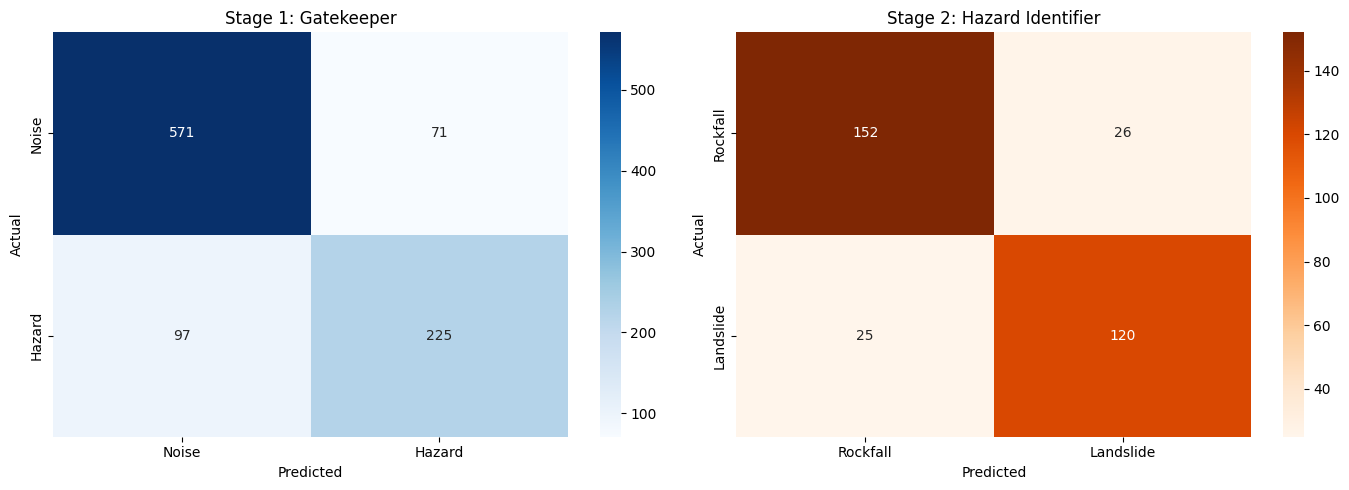

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ==========================================
# --- CONFIGURATION ---
# ==========================================
DATA_FILE = r"D:\seismic\rich_features_dataset_augmented.npz"
SAVE_IMG_PATH = r"D:\seismic\hierarchical_pipeline_results.png"

# 🚀 UPGRADE: Opened the PCA bottleneck from 150 to 400
PCA_COMPONENTS = 400

def train_hierarchical_pipeline():
    print(f"🚀 Loading augmented features from {DATA_FILE}...")
    data = np.load(DATA_FILE)
    X = data['X']
    y = data['y']
    print(f"📊 Augmented Data Shape: {X.shape}")

    # ==========================================
    # STAGE 1: THE GATEKEEPER (Noise vs. Hazard)
    # ==========================================
    print("\n" + "="*50)
    print("🛡️ STAGE 1: TRAINING ENSEMBLE GATEKEEPER")

    y_stage1 = np.where((y == 2) | (y == 3), 0, 1)

    X_train1, X_test1, y_train1, y_test1 = train_test_split(
        X, y_stage1, test_size=0.25, random_state=42, stratify=y_stage1
    )

    # 🚀 UPGRADE: Calculate missing weight for Stage 1 (Noise vs Hazard)
    num_noise = np.sum(y_train1 == 0)
    num_hazards = np.sum(y_train1 == 1)
    stage1_weight = num_noise / (num_hazards + 1e-5)
    print(f"⚖️ Stage 1: Applying positive weight of {stage1_weight:.2f} to prioritize Hazards.")

    # Base XGBoost on previous Grid Search winners + Stage 1 Weight
    xgb_clf1 = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.1, max_depth=5,
        scale_pos_weight=stage1_weight,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'
    )
    # Partner Random Forest
    rf_clf1 = RandomForestClassifier(
        n_estimators=400, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1
    )

    # 🚀 UPGRADE: Soft Voting Ensemble Fusion
    stage1_ensemble = VotingClassifier(estimators=[('xgb', xgb_clf1), ('rf', rf_clf1)], voting='soft')

    stage1_pipeline = Pipeline([
        ('clf', stage1_ensemble)
    ])

    stage1_pipeline.fit(X_train1, y_train1)

    print("\n📝 Stage 1 Evaluation (Ensemble):")
    y_pred1 = stage1_pipeline.predict(X_test1)
    print(classification_report(y_test1, y_pred1, target_names=['Noise (Anthro/Ambient)', 'Hazard (Rock/Land)']))

    # ==========================================
    # STAGE 2: THE HAZARD IDENTIFIER (Rockfall vs Landslide)
    # ==========================================
    print("\n" + "="*50)
    print("⚠️ STAGE 2: TRAINING ENSEMBLE HAZARD IDENTIFIER")

    hazard_mask = (y == 0) | (y == 1)
    X_hazards = X[hazard_mask]
    y_hazards = y[hazard_mask]

    X_train2, X_test2, y_train2, y_test2 = train_test_split(
        X_hazards, y_hazards, test_size=0.25, random_state=42, stratify=y_hazards
    )

    num_rockfalls = np.sum(y_train2 == 0)
    num_landslides = np.sum(y_train2 == 1)
    stage2_weight = num_rockfalls / (num_landslides + 1e-5)
    print(f"⚖️ Stage 2: Applying positive weight of {stage2_weight:.2f} to prioritize Landslides.")

    # Base XGBoost on previous Grid Search winners
    xgb_clf2 = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        scale_pos_weight=stage2_weight,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'
    )
    # Partner Random Forest
    rf_clf2 = RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    )

    stage2_ensemble = VotingClassifier(estimators=[('xgb', xgb_clf2), ('rf', rf_clf2)], voting='soft')

    stage2_pipeline = Pipeline([
        ('clf', stage2_ensemble)
    ])

    stage2_pipeline.fit(X_train2, y_train2)

    print("\n📝 Stage 2 Evaluation (Ensemble):")
    y_pred2 = stage2_pipeline.predict(X_test2)
    print(classification_report(y_test2, y_pred2, target_names=['Rockfall', 'Landslide']))

    # ==========================================
    # VISUALIZATION
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(confusion_matrix(y_test1, y_pred1), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Noise', 'Hazard'], yticklabels=['Noise', 'Hazard'], ax=axes[0])
    axes[0].set_title('Stage 1: Gatekeeper')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    sns.heatmap(confusion_matrix(y_test2, y_pred2), annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Rockfall', 'Landslide'], yticklabels=['Rockfall', 'Landslide'], ax=axes[1])
    axes[1].set_title('Stage 2: Hazard Identifier')
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(SAVE_IMG_PATH)
    print(f"\n🖼️ Saved confusion matrices to '{SAVE_IMG_PATH}'")

    joblib.dump(stage1_pipeline, r"D:\seismic\stage1_gatekeeper.pkl")
    joblib.dump(stage2_pipeline, r"D:\seismic\stage2_hazard.pkl")
    print("💾 Saved XGBoost + RF Ensembles to disk!")

if __name__ == "__main__":
    train_hierarchical_pipeline()

In [ ]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip install xgboost